# Replicating Cascading Failures in Power Grids

## Table of Contents

- [Part 1: Data Preprocessing](#Part-1:-Data-Preprocessing)
  - [1.1 Load the Data](#1.1-Load-the-Data)
  - [1.2 Build the Graphs](#1.2-Build-the-Graphs)
  - [1.3 Add Power as Node Attributes](#1.3-Add-Power-as-Node-Attributes)
- [Part 2: Dynamic Model](#Part-2:-Dynamic-Model)
  - [2.1 Fixed Point Equation](#2.1-Fixed-Point-Equation)
  - [2.2 Initial Line Flows](#2.2-Initial-Line-Flows)
  - [2.3 Overload Rule](#2.3-Overload-Rule)
  - [2.4 Trigger Line](#2.4-Trigger-Line)
  - [2.5 Dynamic Response After the Trigger](#2.5-Dynamic-Response-After-the-Trigger)
  - [2.6 Overloaded Lines After the Trigger](#2.6-Overloaded-Lines-After-the-Trigger)
  - [2.7 Cascade Curves for Different Trigger Lines](#2.7-Cascade-Curves-for-Different-Trigger-Lines)
- [Part 3: Statistics of Dynamical Cascades](#Part-3:-Statistics-of-Dynamical-Cascades)
  - [3.1 Average Damage at the Current Tolerance](#3.1-Average-Damage-at-the-Current-Tolerance)
  - [3.2 Damage as a Function of the Tolerance](#3.2-Damage-as-a-Function-of-the-Tolerance)
- [Part 4: Distribution of Cascade Sizes](#Part-4:-Distribution-of-Cascade-Sizes)
  - [4.1 Spanish Distributed Power](#4.1-Spanish-Distributed-Power)
  - [4.2 Spanish Scenarios](#4.2-Spanish-Scenarios)
  - [4.3 French Scenarios](#4.3-French-Scenarios)
  - [4.5 Combined Spain and France](#4.5-Combined-Spain-and-France)

## Part 1: Data Preprocessing

In [1]:
# Setup
import pickle
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import root
from scipy.integrate import solve_ivp
from tqdm.auto import tqdm

cache_dir = Path('cache')
cache_dir.mkdir(exist_ok=True)

plt.style.use('default')
%matplotlib inline

### 1.1 Load the Data

In [2]:
countries = ['French', 'GB', 'Spanish']
scenarios = ['CentralizedPower', 'DistributedPower', 'HeterogeneousCoupling']

The data was provided by the author's [supplementary materials](https://osf.io/jz4m6/overview).

In [3]:
matrices = {}
powers = {}

for country in countries:
    for scenario in scenarios:
        name = f'{country}{scenario}'

        matrices[name] = pd.read_csv(f'NetWorkData/{name}_Matrix.csv', header=None)
        powers[name] = pd.read_csv(f'NetWorkData/{name}_Power.csv', header=None)

        power_values = []

        for x in powers[name][0]: # I had some issues with fractions
            if '/' in str(x):
                a, b = str(x).split('/')
                value = float(a) / float(b)
            else:
                value = float(x)

            power_values.append(value)

        powers[name][0] = power_values

### 1.2 Build the Graphs

In [4]:
graphs = {}

for name in matrices:
    graphs[name] = nx.from_pandas_adjacency(matrices[name])

There are nine graphs that are considered in the paper by Schäfer et al.(2018): the three scenarios (distributed power, centralized power, heterogenous coupling) in each of the countries (France, UK, Spain).

In [5]:
graph_overview = []

for name in graphs:
    graph_overview.append({
        'Graph': name,
        'Nodes': graphs[name].number_of_nodes(),
        'Edges': graphs[name].number_of_edges()})

pd.DataFrame(graph_overview)

,Graph,Nodes,Edges
0,FrenchCentralizedPower,146,223
1,FrenchDistributedPower,146,223
2,FrenchHeterogeneousCoupling,146,223
3,GBCentralizedPower,120,165
4,GBDistributedPower,120,165
5,GBHeterogeneousCoupling,120,165
6,SpanishCentralizedPower,98,175
7,SpanishDistributedPower,98,175
8,SpanishHeterogeneousCoupling,98,175


In [6]:
graph_properties = []

for country in ['French', 'GB', 'Spanish']:
    G = graphs[f'{country}DistributedPower']

    graph_properties.append({
        'Country': country,
        'Density': nx.density(G),
        'Global clustering coefficient': nx.transitivity(G),
        'Average clustering coefficient': nx.average_clustering(G)})

pd.DataFrame(graph_properties)

,Country,Density,Global clustering coefficient,Average clustering coefficient
0,French,0.021068,0.260116,0.279631
1,GB,0.023109,0.121037,0.117500
2,Spanish,0.036819,0.353204,0.317760


The Spanish grid is the most densely connected network and also has the highest clustering, which suggests the strongest local interconnectedness among the three cases. In contrast, the GB grid has a similar density to the French grid but much lower clustering, indicating a less locally clustered structure. The French grid lies between these two extremes, with moderate density and clearly higher clustering than GB.

### 1.3 Add Power as Node Attributes

In [7]:
for name in graphs:
    for node in graphs[name].nodes:
        graphs[name].nodes[node]['power'] = powers[name].iloc[node, 0]

In [11]:
G = graphs['SpanishDistributedPower']

node_power_table = pd.DataFrame({
    'Node': list(G.nodes())[:5],
    'Power': [G.nodes[node]['power'] for node in list(G.nodes())[:5]]})

node_power_table

,Node,Power
0,0,-1.0
1,1,1.0
2,2,1.0
3,3,-1.0
4,4,1.0


As in the paper, the power values are normalized to `-1` and `1` because the model distinguishes only between two node roles: consumers and generators. A value of `1` represents a power-producing node, whereas `-1` represents a power-consuming node.


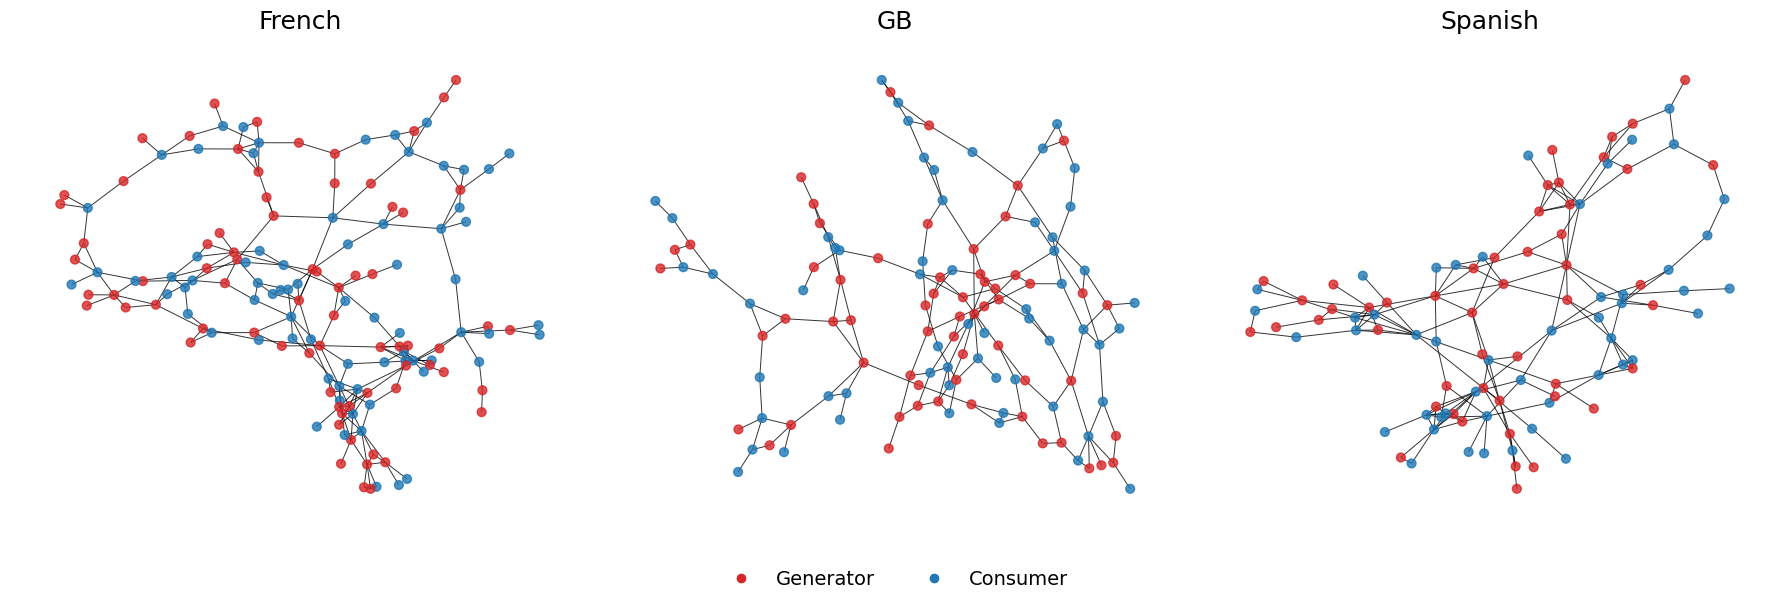

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=8, label='Generator'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='Consumer')]

for i, country in enumerate(['French', 'GB', 'Spanish']):
    G = graphs[f'{country}DistributedPower']
    pos = nx.spring_layout(G, seed=42)
    node_colors = ['tab:red' if G.nodes[node]['power'] > 0 else 'tab:blue' for node in G.nodes()]

    nx.draw(G, pos, ax=axes[i], node_color=node_colors, node_size=40, width=0.7, alpha=0.8, with_labels=False)
    axes[i].set_title(country, fontsize=18)
    axes[i].axis('off')

fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 1])

## Part 2: Dynamic Model

### 2.1 Fixed Point Equation

The first step is to compute the stationary operating point of the grid. The idea is to find node phases for which power injection and network transport exactly balance, so the system is in equilibrium before removal of any line.

$$
P_i + \sum_j K_{ij} \sin(\theta_j - \theta_i) = 0
$$

Here, $P_i$ is the power injected or consumed at node $i$, $K_{ij}$ is the coupling strength of line $(i,j)$, and $\theta_i$ is the phase angle at node $i$. I fix one reference angle to zero (as the authors did) and solve the remaining nonlinear equations numerically.

In [13]:
# For simplicity I develop the code for Spain with Distributed Power
country = 'Spanish'
scenario = 'DistributedPower'

K = matrices[f'{country}{scenario}'].to_numpy(dtype=float)
P = powers[f'{country}{scenario}'][0].to_numpy(dtype=float)

number_of_nodes = len(P)
starting_point = np.zeros(number_of_nodes - 1) # I have to set the first angle to zero

Without secondary control, only angle differences matter. Therefore, I fix one reference angle to $theta_1 = 0$ to obtain a unique solution.

In [14]:
def fixed_point_equations(theta_rest):
    """
    Return the fixed-point residuals for all nodes except the reference node.
    """
    theta = np.concatenate(([0.0], theta_rest))

    residuals = []

    for i in range(1, number_of_nodes):
        coupling_sum = 0.0

        for j in range(number_of_nodes):
            coupling_sum += K[i, j] * np.sin(theta[j] - theta[i]) # see formula above

        residuals.append(P[i] + coupling_sum)

    return np.array(residuals)

Solve the nonlinear fixed-point equations numerically and reconstruct the full phase vector by adding the reference angle $theta_1 = 0$.

In [15]:
fixed_point_solution = root(fixed_point_equations, starting_point)

theta_fixed = np.concatenate(([0.0], fixed_point_solution.x))

In [16]:
theta_table = pd.DataFrame({'Node': np.arange(number_of_nodes),
                            'Power': P,
                            'Theta*': theta_fixed})

theta_table.head(5)

,Node,Power,Theta*
0,0,-1.0,0.000000
1,1,1.0,0.133631
2,2,1.0,0.066816
3,3,-1.0,-0.054114
4,4,1.0,0.060185


### 2.2 Initial Line Flows

I now use the fixed-point angles to compute the flow on every transmission line in the undisturbed grid.

$$
F_{ij} = \left|K_{ij}\sin(\theta_i^* - \theta_j^*)\right|
$$

These initial flows are important because the original code uses them to identify redundant lines and to define overload thresholds.

In [18]:
edge_flows = []

for i in range(number_of_nodes):
    for j in range(i + 1, number_of_nodes):
        if K[i, j] > 0: # check if an edge exists between the two nodes
            flow = abs(K[i, j] * np.sin(theta_fixed[i] - theta_fixed[j]))

            edge_flows.append({'node_i': i,'node_j': j,
                               'coupling': K[i, j],'initial_flow': flow})

Store the line flows in a table and sort them from high to low.

In [19]:
edge_flow_table = pd.DataFrame(edge_flows)
edge_flow_table = edge_flow_table.sort_values('initial_flow', ascending=False).reset_index(drop=True)

edge_flow_table.head(5)

,node_i,node_j,coupling,initial_flow
0,56,58,5.0,2.593740
1,56,59,5.0,2.567515
2,16,19,5.0,2.544210
3,26,29,5.0,2.300228
4,29,52,5.0,2.274668


The original paper also removes lines with essentially zero flow, because they do not carry load in the fixed point.

In [20]:
redundant_lines = edge_flow_table[edge_flow_table['initial_flow'] < 1e-8].copy()

redundant_summary = pd.DataFrame({
    'Quantity': ['Number of lines', 'Number of redundant lines'],
    'Value': [len(edge_flow_table), len(redundant_lines)]})

print(redundant_summary)

                    Quantity  Value
0            Number of lines    175
1  Number of redundant lines      2


This matches the authors' result: the two redundant lines are $(42,46)$ and $(82,83)$.

### 2.3 Overload Rule

Next, I define the overload rule that is later used during the cascade simulation.

In [21]:
tolerance_alpha = 0.52 # from the paper

The authors consider two ways to define overload. In the Spanish example, the current flow on a line is compared to a fixed fraction of its line capacity. This means that a line is considered overloaded when its flow becomes larger than $\alpha K_{ij}$, where $K_{ij}$ is the coupling strength of the line and $\alpha$ is the tolerance parameter. This is the rule used in the Spanish example of the authors' notebook.

In [22]:
edge_flow_table['capacity_threshold'] = tolerance_alpha * edge_flow_table['coupling']
edge_flow_table['initially_overloaded'] = edge_flow_table['initial_flow'] >= edge_flow_table['capacity_threshold']

edge_flow_table.head(5)

,node_i,node_j,coupling,initial_flow,capacity_threshold,initially_overloaded
0,56,58,5.0,2.593740,2.6,False
1,56,59,5.0,2.567515,2.6,False
2,16,19,5.0,2.544210,2.6,False
3,26,29,5.0,2.300228,2.6,False
4,29,52,5.0,2.274668,2.6,False


### 2.4 Trigger Line

I now define the line whose failure starts the cascade. In the authors' notebook for the Spanish distributed-power grid, the trigger line is chosen as the 35th line in the edge list.

In [23]:
list_of_edges = list(zip(edge_flow_table['node_i'], edge_flow_table['node_j']))

trigger_index = 34
trigger_line = list_of_edges[trigger_index]

To prepare the cascade simulation, I remove this line from the graph and compare the network before and after the trigger event.

In [24]:
triggered_graph = graphs[f'{country}{scenario}'].copy()
triggered_graph.remove_edge(*trigger_line)

triggered_matrix = K.copy()
triggered_matrix[trigger_line[0], trigger_line[1]] = 0.0
triggered_matrix[trigger_line[1], trigger_line[0]] = 0.0

At this point, I have only applied the initial line failure structurally. In the next step, I let the system evolve dynamically after this trigger event.

### 2.5 Dynamic Response After the Trigger

In this step, I study the immediate dynamic response to the trigger. The goal is to show that the intact fixed point stops being an equilibrium once the trigger line is removed at $t = 1$.

$$
\dot{\theta}_i = \omega_i
$$

$$
I_i\dot{\omega}_i = P_i - \gamma_i \omega_i + \sum_j K_{ij}\sin(\theta_j - \theta_i)
$$

This is the same swing-equation structure as in the paper. In this equation, $\omega_i$ denotes the frequency deviation of node i, so it measures how strongly the node departs from the synchronized operating state. The parameter $I_i$ represents the inertia of node i, which controls how strongly its frequency reacts to imbalances, while $\gamma_i$ is a damping term that counteracts frequency deviations and stabilizes the dynamics.

In this notebook, the inertia is chosen uniformly as $I_i = 1$ for all nodes, and the damping is set to $\gamma_i$ = 0.1, following the authors' setup.

For $t < t_{trigger}$ the intact network stays at the fixed point, and for $t \geq t_{trigger}$ the line removal induces a non-trivial time evolution.

In [25]:
I = np.ones(number_of_nodes)
gamma = 0.1 # from the author's code

t_start = 0.0
t_trigger = 1.0 # from the author's code
t_end = 10.0 # from the author's code
time_grid = np.linspace(t_start, t_end, 1000)

I use the fixed point of the intact network as the initial condition. This ensures that any later motion is caused by the trigger event itself and not by an arbitrary perturbation of the initial state.

In [26]:
initial_theta = theta_fixed.copy()
initial_omega = np.zeros(number_of_nodes)
initial_state = np.concatenate([initial_theta, initial_omega])

In [27]:
def swing_equation_after_trigger(t, state):
    """
    Return the swing-equation derivatives before and after the trigger event.
    """
    theta = state[:number_of_nodes]
    omega = state[number_of_nodes:]

    if t < t_trigger:
        current_matrix = K
    else:
        current_matrix = triggered_matrix

    dtheta_dt = omega
    domega_dt = np.zeros(number_of_nodes)

    for i in range(number_of_nodes):
        coupling_sum = 0.0

        for j in range(number_of_nodes):
            coupling_sum += current_matrix[i, j] * np.sin(theta[j] - theta[i])

        domega_dt[i] = (P[i] - gamma * omega[i] + coupling_sum) / I[i]

    return np.concatenate([dtheta_dt, domega_dt])

I now solve the differential equations numerically and extract the phase and frequency trajectories. The only change at $t = 1$ is the switch from the original coupling matrix to the triggered one.

In [28]:
dynamic_solution = solve_ivp(swing_equation_after_trigger,
                             (t_start, t_end), initial_state, t_eval=time_grid)

In [29]:
theta_trajectory = dynamic_solution.y[:number_of_nodes]
omega_trajectory = dynamic_solution.y[number_of_nodes:]

The plot below shows the frequency trajectories before and after the trigger. Before $t = 1$ the system stays at the fixed point, and after the trigger the removed line induces the dynamics that later drives the cascade.

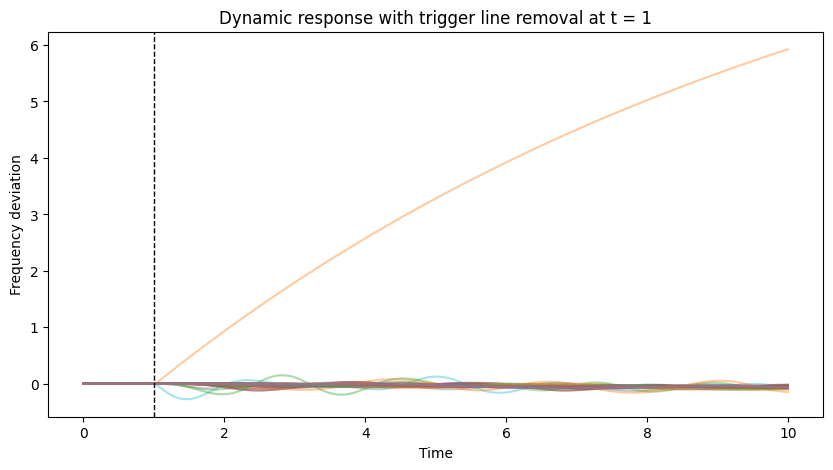

In [30]:
plt.figure(figsize=(10, 5))

for i in range(number_of_nodes):
    plt.plot(dynamic_solution.t, omega_trajectory[i], alpha=0.4)

plt.axvline(t_trigger, color='black', linestyle='--', linewidth=1)
plt.xlabel('Time')
plt.ylabel('Frequency deviation')
plt.title('Dynamic response with trigger line removal at t = 1')
plt.show()

Before the trigger at $t = 1$, all frequency deviations remain at zero, confirming that the intact network is in a steady synchronized state. After the trigger, most nodes show only small oscillations around zero, but one trajectory departs strongly from the synchronized regime, indicating that the line removal induces a substantial dynamical imbalance that can initiate a cascade.

This step only shows the immediate dynamics after the trigger. The actual cascade result comes in the next step.

### 2.6 Overloaded Lines After the Trigger

I now switch to an iterative cascade procedure, much closer to the original code.

$$
F_{ij}(t) = \left|K_{ij}(t)\sin(\theta_i(t) - \theta_j(t))\right|
$$

A line is classified as overloaded when its dynamic flow exceeds the threshold $\alpha K_{ij}$. When this happens, I remove the line and restart the simulation from that event time, just as the original code updates its dynamic coupling matrix.

In [32]:
candidate_lines = list(zip(edge_flow_table['node_i'], edge_flow_table['node_j']))
candidate_lines = [edge for edge in candidate_lines if edge != tuple(trigger_line)]

time_step = 0.01 # my decision

In [34]:
def swing_equation_with_matrix(t, state, active_matrix):
    """
    Return the swing-equation derivatives for a given coupling matrix.
    """
    theta = state[:number_of_nodes] # see 2.5
    omega = state[number_of_nodes:]

    dtheta_dt = omega
    domega_dt = np.zeros(number_of_nodes)

    for i in range(number_of_nodes):
        coupling_sum = 0.0

        for j in range(number_of_nodes):
            coupling_sum += active_matrix[i, j] * np.sin(theta[j] - theta[i])

        domega_dt[i] = (P[i] - gamma * omega[i] + coupling_sum) / I[i]

    return np.concatenate([dtheta_dt, domega_dt])


def first_overloaded_lines(solution, active_matrix):
    """
    Return the first set of overloaded lines detected along a solution trajectory.
    """
    theta_solution = solution.y[:number_of_nodes]

    for time_index, current_time in enumerate(solution.t):
        overloaded_at_time = []

        for edge in candidate_lines:
            i, j = edge

            if active_matrix[i, j] == 0:
                continue

            flow = abs(active_matrix[i, j] * np.sin(theta_solution[i, time_index] - theta_solution[j, time_index]))
            threshold = tolerance_alpha * K[i, j]

            if flow >= threshold:
                overloaded_at_time.append({
                    'node_i': i,
                    'node_j': j,
                    'failure_time': current_time,
                    'flow': flow,
                    'threshold': threshold})

        if len(overloaded_at_time) > 0:
            return overloaded_at_time, time_index

    return [], None

I now simulate the cascade iteratively. Before the trigger, the intact network stays at the fixed point. After the trigger, I repeatedly search for the earliest overloaded line and remove it.

In [37]:
example_cascade_cache_file = cache_dir / 'spanish_example_cascade.pkl'

example_cascade_cache = None

if example_cascade_cache_file.exists():
    with example_cascade_cache_file.open('rb') as file:
        loaded_example_cascade_cache = pickle.load(file)

    same_settings = (
        loaded_example_cascade_cache.get('country') == country and
        loaded_example_cascade_cache.get('scenario') == scenario and
        loaded_example_cascade_cache.get('trigger_line') == tuple(trigger_line) and
        loaded_example_cascade_cache.get('time_step') == time_step and
        loaded_example_cascade_cache.get('t_start') == t_start and
        loaded_example_cascade_cache.get('t_trigger') == t_trigger and
        loaded_example_cascade_cache.get('t_end') == t_end and
        loaded_example_cascade_cache.get('tolerance_alpha') == tolerance_alpha)

    if same_settings:
        example_cascade_cache = loaded_example_cascade_cache

if example_cascade_cache is None:
    active_matrix = K.copy()
    current_time = t_start
    current_state = initial_state.copy()

    lines_cut = [{'node_i': trigger_line[0], 'node_j': trigger_line[1], 'failure_time': t_trigger, 'reason': 'trigger'}]
    cascade_segments = []

    while current_time < t_end:
        if current_time < t_trigger:
            segment_end = t_trigger
        else:
            segment_end = t_end

        if segment_end - current_time < 1e-12:
            break

        segment_times = np.arange(current_time, segment_end, time_step)
        segment_times = segment_times[(segment_times >= current_time) & (segment_times <= segment_end)]

        if len(segment_times) == 0 or abs(segment_times[-1] - segment_end) > 1e-12:
            segment_times = np.append(segment_times, segment_end)

        segment_times = np.unique(np.round(segment_times, 12))

        segment_solution = solve_ivp(swing_equation_with_matrix,
                                     (current_time, segment_end), current_state,
                                     t_eval=segment_times, args=(active_matrix,))

        cascade_segments.append(segment_solution)

        if current_time < t_trigger:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_trigger
            active_matrix[trigger_line[0], trigger_line[1]] = 0.0
            active_matrix[trigger_line[1], trigger_line[0]] = 0.0
            continue

        overloaded_now, failure_index = first_overloaded_lines(segment_solution, active_matrix)

        if len(overloaded_now) == 0:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_end
            break

        failure_time = overloaded_now[0]['failure_time']
        current_state = segment_solution.y[:, failure_index].copy()
        current_time = failure_time

        for failed_line in overloaded_now:
            i = failed_line['node_i']
            j = failed_line['node_j']
            active_matrix[i, j] = 0.0
            active_matrix[j, i] = 0.0
            failed_line['reason'] = 'overload'
            lines_cut.append(failed_line)

    final_omega = cascade_segments[-1].y[number_of_nodes:, -1]

    example_cascade_cache_payload = {
        'country': country,
        'scenario': scenario,
        'trigger_line': tuple(trigger_line),
        'time_step': time_step,
        't_start': t_start,
        't_trigger': t_trigger,
        't_end': t_end,
        'tolerance_alpha': tolerance_alpha,
        'lines_cut': lines_cut,
        'final_omega': final_omega.tolist()}

    with example_cascade_cache_file.open('wb') as file:
        pickle.dump(example_cascade_cache_payload, file)
else:
    lines_cut = list(example_cascade_cache['lines_cut'])
    final_omega = np.array(example_cascade_cache['final_omega'])

The resulting line failures can now be summarized. For the Spanish distributed-power example, this is the main replication result.

In [38]:
lines_cut_table = pd.DataFrame(lines_cut)
lines_cut_table = lines_cut_table.sort_values('failure_time').reset_index(drop=True)

omega_not_synchronized_threshold = 0.02 * 2 * np.pi
nodes_not_synchronized = np.where(np.abs(final_omega) > omega_not_synchronized_threshold)[0]

cascade_summary = pd.DataFrame({
    'Quantity': ['Number of lines cut', 'Number of nodes not synchronized'],
    'Value': [len(lines_cut_table), len(nodes_not_synchronized)]})

print(cascade_summary)

                           Quantity  Value
0               Number of lines cut     14
1  Number of nodes not synchronized     98


This reproduces the authors' result: 14 lines are cut and 98 nodes are not synchronized after the cascade.

### 2.7 Cascade Curves for Different Trigger Lines

I now use the same cascade logic for many trigger lines. The scan takes a while...

In [ ]:
def run_cascade_for_trigger(trigger_line, t_end_for_curve=20.0, local_time_step=None):
    """
    Simulate the dynamic cascade for a given trigger line and return the resulting line failures and unsynchronized nodes.
    """
    active_matrix = K.copy()
    current_time = t_start
    current_state = initial_state.copy()
    step_size = time_step if local_time_step is None else local_time_step
    lines_cut_local = [{'node_i': trigger_line[0], 'node_j': trigger_line[1], 'failure_time': t_trigger, 'reason': 'trigger'}]
    cascade_segments_local = []
    candidate_lines_for_trigger = [edge for edge in list_of_edges if edge != tuple(trigger_line)]

    while current_time < t_end_for_curve:
        if current_time < t_trigger:
            segment_end = t_trigger
        else:
            segment_end = t_end_for_curve

        if segment_end - current_time < 1e-12:
            break

        segment_times = np.arange(current_time, segment_end, step_size)
        segment_times = segment_times[(segment_times >= current_time) & (segment_times <= segment_end)]

        if len(segment_times) == 0 or abs(segment_times[-1] - segment_end) > 1e-12:
            segment_times = np.append(segment_times, segment_end)

        segment_times = np.unique(np.round(segment_times, 12))

        segment_solution = solve_ivp(swing_equation_with_matrix,
                                     (current_time, segment_end), current_state,
                                     t_eval=segment_times, args=(active_matrix,), rtol=1e-6, atol=1e-8)

        cascade_segments_local.append(segment_solution)

        if current_time < t_trigger:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_trigger
            active_matrix[trigger_line[0], trigger_line[1]] = 0.0
            active_matrix[trigger_line[1], trigger_line[0]] = 0.0
            continue

        theta_solution = segment_solution.y[:number_of_nodes]
        overloaded_now = []
        failure_index = None

        for time_index, current_segment_time in enumerate(segment_solution.t):
            overloaded_at_time = []

            for edge in candidate_lines_for_trigger:
                i, j = edge

                if active_matrix[i, j] == 0:
                    continue

                flow = abs(active_matrix[i, j] * np.sin(theta_solution[i, time_index] - theta_solution[j, time_index]))
                threshold = tolerance_alpha * K[i, j]

                if flow >= threshold:
                    overloaded_at_time.append({
                        'node_i': i,
                        'node_j': j,
                        'failure_time': current_segment_time,
                        'flow': flow,
                        'threshold': threshold})

            if len(overloaded_at_time) > 0:
                overloaded_now = overloaded_at_time
                failure_index = time_index
                break

        if len(overloaded_now) == 0:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_end_for_curve
            break

        current_state = segment_solution.y[:, failure_index].copy()
        current_time = overloaded_now[0]['failure_time']

        for failed_line in overloaded_now:
            i = failed_line['node_i']
            j = failed_line['node_j']
            active_matrix[i, j] = 0.0
            active_matrix[j, i] = 0.0
            failed_line['reason'] = 'overload'
            lines_cut_local.append(failed_line)

    lines_cut_table_local = pd.DataFrame(lines_cut_local)
    lines_cut_table_local = lines_cut_table_local.sort_values('failure_time').reset_index(drop=True)

    final_omega_local = cascade_segments_local[-1].y[number_of_nodes:, -1]
    nodes_not_synchronized_local = np.where(np.abs(final_omega_local) > omega_not_synchronized_threshold)[0]

    return lines_cut_table_local, len(nodes_not_synchronized_local)

Line 1 is the same trigger line as above. I now compute the average over all trigger lines and store intermediate results.

In [40]:
spanish_graph = graphs[f'{country}{scenario}']
spanish_positions = nx.spring_layout(spanish_graph, seed=42)

redundant_lines_python = set(zip(redundant_lines['node_i'], redundant_lines['node_j']))
valid_trigger_lines = [edge for edge in list_of_edges if edge not in redundant_lines_python]

average_time_step = 0.1
trigger_stride = 1
sampled_trigger_lines = valid_trigger_lines[::trigger_stride]
cache_file = cache_dir / 'trigger_scan_cache_full.pkl'

cache_data = None

if cache_file.exists():
    with cache_file.open('rb') as file:
        loaded_cache = pickle.load(file)

    same_settings = (
        loaded_cache.get('country') == country and
        loaded_cache.get('scenario') == scenario and
        loaded_cache.get('average_time_step') == average_time_step and
        loaded_cache.get('trigger_stride') == trigger_stride and
        loaded_cache.get('t_end_for_curve') == 20.0 and
        loaded_cache.get('tolerance_alpha') == tolerance_alpha)

    if same_settings:
        cache_data = loaded_cache

if cache_data is None:
    cache_data = {
        'country': country,
        'scenario': scenario,
        'average_time_step': average_time_step,
        'trigger_stride': trigger_stride,
        't_end_for_curve': 20.0,
        'tolerance_alpha': tolerance_alpha,
        'trigger_scan_rows': [],
        'cascade_results_by_trigger': {}}

cascade_results_by_trigger = {}

for edge_key, edge_table in cache_data['cascade_results_by_trigger'].items():
    cascade_results_by_trigger[tuple(edge_key)] = pd.DataFrame(edge_table)

trigger_scan_rows = list(cache_data['trigger_scan_rows'])
finished_trigger_lines = {tuple(row['trigger_line']) for row in trigger_scan_rows}
missing_trigger_lines = [edge for edge in sampled_trigger_lines if edge not in finished_trigger_lines]

for trigger_index, trigger_edge in enumerate(tqdm(missing_trigger_lines, desc='Scanning trigger lines'), start=len(trigger_scan_rows) + 1):
    lines_cut_table_local, unsynchronized_nodes_local = run_cascade_for_trigger(trigger_edge, local_time_step=average_time_step)
    cascade_results_by_trigger[trigger_edge] = lines_cut_table_local

    trigger_row = {
        'trigger_line': trigger_edge,
        'trigger_index': trigger_index,
        'node_i_python': trigger_edge[0],
        'node_j_python': trigger_edge[1],
        'node_i_authors': trigger_edge[0] + 1,
        'node_j_authors': trigger_edge[1] + 1,
        'number_of_lines_cut': len(lines_cut_table_local),
        'number_of_unsynchronized_nodes': unsynchronized_nodes_local}

    trigger_scan_rows.append(trigger_row)

    cache_payload = {
        'country': country,
        'scenario': scenario,
        'average_time_step': average_time_step,
        'trigger_stride': trigger_stride,
        't_end_for_curve': 20.0,
        'tolerance_alpha': tolerance_alpha,
        'trigger_scan_rows': trigger_scan_rows,
        'cascade_results_by_trigger': {edge: table.to_dict('records') for edge, table in cascade_results_by_trigger.items()}}

    with cache_file.open('wb') as file:
        pickle.dump(cache_payload, file)

trigger_scan_table = pd.DataFrame(trigger_scan_rows)
trigger_scan_table = trigger_scan_table.sort_values('trigger_index').reset_index(drop=True)

line_1 = tuple(trigger_line)

line_1_table = pd.DataFrame([
    {'Label': 'Line 1', 'Python nodes': line_1, 'Authors nodes': (line_1[0] + 1, line_1[1] + 1), 'Number of lines cut': len(lines_cut_table), 'Trigger lines in average': len(sampled_trigger_lines)}])

Scanning trigger lines: 0it [00:00, ?it/s]

I now choose a concrete Line 2. I take the leftmost line among the single-failure candidates and add it to the network plot.

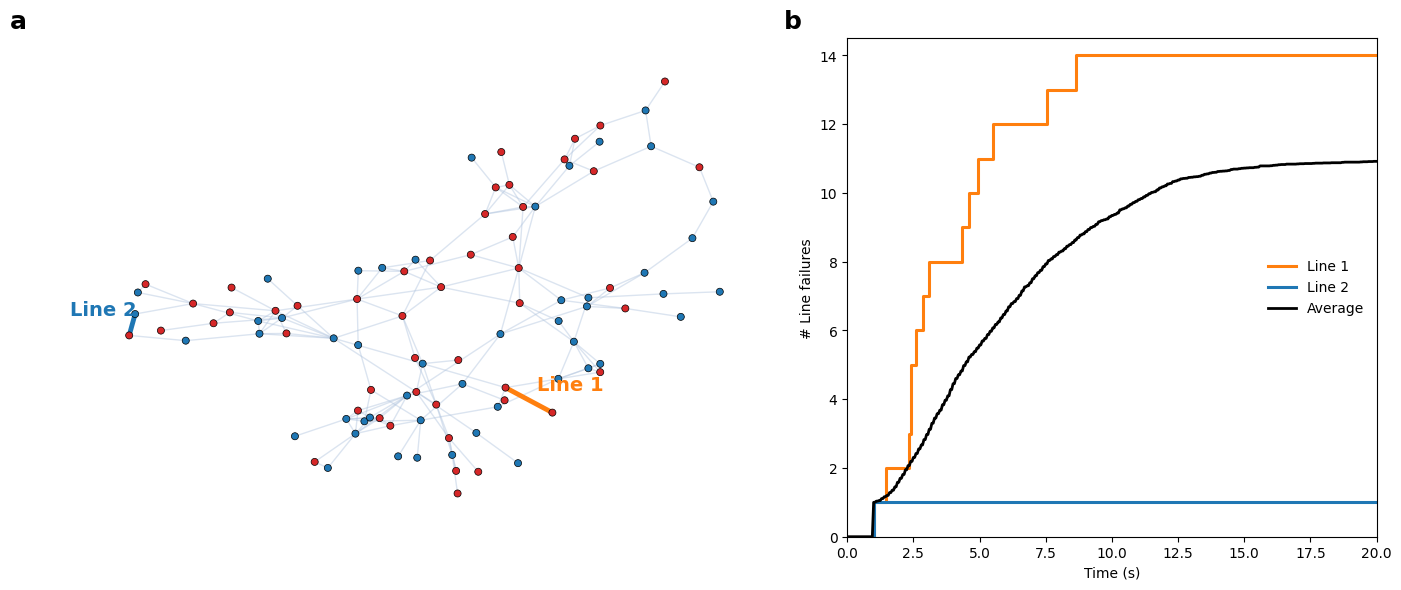

In [42]:
plot_times = np.arange(0.0, 20.01, 0.05)

line_1_failure_times = lines_cut_table['failure_time'].to_numpy()
line_1_curve = np.array([np.sum(line_1_failure_times <= current_time) for current_time in plot_times])

line_1_midpoint = np.mean(np.vstack([spanish_positions[line_1[0]], spanish_positions[line_1[1]]]), axis=0)

single_failure_candidates = [tuple(edge) for edge in trigger_scan_table.loc[trigger_scan_table['number_of_lines_cut'] == 1, 'trigger_line']]
single_failure_candidates = [edge for edge in single_failure_candidates if edge != line_1 and edge in cascade_results_by_trigger]

line_2 = min(single_failure_candidates,
             key=lambda edge: 0.5 * (spanish_positions[edge[0]][0] + spanish_positions[edge[1]][0]))
line_2_midpoint = np.mean(np.vstack([spanish_positions[line_2[0]], spanish_positions[line_2[1]]]), axis=0)

line_2_failure_times = cascade_results_by_trigger[line_2]['failure_time'].to_numpy()
line_2_curve = np.array([np.sum(line_2_failure_times <= current_time) for current_time in plot_times])

all_curves = []

for trigger_edge in sampled_trigger_lines:
    failure_times = cascade_results_by_trigger[trigger_edge]['failure_time'].to_numpy()
    curve = np.array([np.sum(failure_times <= current_time) for current_time in plot_times])
    all_curves.append(curve)

average_curve = np.mean(all_curves, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.35, 1.0]})

node_colors = ['tab:red' if spanish_graph.nodes[node]['power'] > 0 else 'tab:blue' for node in spanish_graph.nodes()]

nx.draw_networkx_edges(spanish_graph, spanish_positions, ax=axes[0], width=1.0, alpha=0.45, edge_color='lightsteelblue')
nx.draw_networkx_nodes(spanish_graph, spanish_positions, ax=axes[0], node_color=node_colors, node_size=26, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(spanish_graph, spanish_positions, ax=axes[0], edgelist=[line_1], width=3.5, edge_color='tab:orange')
nx.draw_networkx_edges(spanish_graph, spanish_positions, ax=axes[0], edgelist=[line_2], width=3.5, edge_color='tab:blue')
axes[0].text(line_1_midpoint[0] + 0.02, line_1_midpoint[1] + 0.04, 'Line 1', color='tab:orange', fontsize=14, weight='bold')
axes[0].text(line_2_midpoint[0] - 0.16, line_2_midpoint[1] + 0.04, 'Line 2', color='tab:blue', fontsize=14, weight='bold')
axes[0].text(-0.08, 1.02, 'a', transform=axes[0].transAxes, fontsize=18, weight='bold')
axes[0].axis('off')

axes[1].step(plot_times, line_1_curve, where='post', color='tab:orange', linewidth=2.2, label='Line 1')
axes[1].step(plot_times, line_2_curve, where='post', color='tab:blue', linewidth=2.2, label='Line 2')
axes[1].plot(plot_times, average_curve, color='black', linewidth=2.0, label='Average')
axes[1].text(-0.12, 1.02, 'b', transform=axes[1].transAxes, fontsize=18, weight='bold')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('# Line failures')
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, max(14.5, line_1_curve.max() + 0.5))
axes[1].legend(frameon=False, loc='center right')

plt.tight_layout()
plt.show()

## Part 3: Statistics of Dynamical Cascades

### 3.1 Average Damage at the Current Tolerance

Before sweeping over many values of $\alpha$, I first summarize the dynamic cascade statistics for the current case $\alpha = 0.52$.

In [43]:
average_lines_cut = trigger_scan_table['number_of_lines_cut'].mean()
average_unsynchronized_nodes = trigger_scan_table['number_of_unsynchronized_nodes'].mean()

average_line_failure_share = 100 * average_lines_cut / spanish_graph.number_of_edges()
average_unsynchronized_share = 100 * average_unsynchronized_nodes / number_of_nodes

dynamic_statistics_table = pd.DataFrame([
    {'Quantity': 'Average line failures', 'Value': average_lines_cut},
    {'Quantity': 'Average unsynchronized nodes', 'Value': average_unsynchronized_nodes},
    {'Quantity': 'Average line failures [%]', 'Value': average_line_failure_share},
    {'Quantity': 'Average unsynchronized nodes [%]', 'Value': average_unsynchronized_share}])

dynamic_statistics_table['Value'] = dynamic_statistics_table['Value'].round(3)
dynamic_statistics_table

,Quantity,Value
0,Average line failures,10.919
1,Average unsynchronized nodes,68.572
2,Average line failures [%],6.239
3,Average unsynchronized nodes [%],69.972


The main quantity for the future line-failure plot is the average final number of failed lines. The main quantity for the future synchronization plot is the average final number of unsynchronized nodes.

### 3.2 Damage as a Function of the Tolerance

I now vary the tolerance parameter $\alpha$ and compare dynamic and static cascades. I use only a predefined set of tolerance values and a small sampled set of trigger lines, due to computability reason.

In [44]:
def run_cascade_for_trigger_with_alpha(trigger_line, alpha_value, t_end_for_curve=20.0, local_time_step=0.1):
    """
    Simulate the dynamic cascade for a given trigger line and tolerance value and return the resulting line failures and unsynchronized nodes.
    """
    active_matrix = K.copy()
    current_time = t_start
    current_state = initial_state.copy()
    lines_cut_local = [{'node_i': trigger_line[0], 'node_j': trigger_line[1], 'failure_time': t_trigger, 'reason': 'trigger'}]
    cascade_segments_local = []
    candidate_lines_for_trigger = [edge for edge in list_of_edges if edge != tuple(trigger_line)]

    while current_time < t_end_for_curve:
        if current_time < t_trigger:
            segment_end = t_trigger
        else:
            segment_end = t_end_for_curve

        if segment_end - current_time < 1e-12:
            break

        segment_times = np.arange(current_time, segment_end, local_time_step)
        segment_times = segment_times[(segment_times >= current_time) & (segment_times <= segment_end)]

        if len(segment_times) == 0 or abs(segment_times[-1] - segment_end) > 1e-12:
            segment_times = np.append(segment_times, segment_end)

        segment_times = np.unique(np.round(segment_times, 12))

        segment_solution = solve_ivp(swing_equation_with_matrix,
                                     (current_time, segment_end), current_state,
                                     t_eval=segment_times, args=(active_matrix,), rtol=1e-6, atol=1e-8)

        cascade_segments_local.append(segment_solution)

        if current_time < t_trigger:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_trigger
            active_matrix[trigger_line[0], trigger_line[1]] = 0.0
            active_matrix[trigger_line[1], trigger_line[0]] = 0.0
            continue

        theta_solution = segment_solution.y[:number_of_nodes]
        overloaded_now = []
        failure_index = None

        for time_index, current_segment_time in enumerate(segment_solution.t):
            overloaded_at_time = []

            for edge in candidate_lines_for_trigger:
                i, j = edge

                if active_matrix[i, j] == 0:
                    continue

                flow = abs(active_matrix[i, j] * np.sin(theta_solution[i, time_index] - theta_solution[j, time_index]))
                threshold = alpha_value * K[i, j]

                if flow >= threshold:
                    overloaded_at_time.append({
                        'node_i': i,
                        'node_j': j,
                        'failure_time': current_segment_time,
                        'flow': flow,
                        'threshold': threshold})

            if len(overloaded_at_time) > 0:
                overloaded_now = overloaded_at_time
                failure_index = time_index
                break

        if len(overloaded_now) == 0:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_end_for_curve
            break

        current_state = segment_solution.y[:, failure_index].copy()
        current_time = overloaded_now[0]['failure_time']

        for failed_line in overloaded_now:
            i = failed_line['node_i']
            j = failed_line['node_j']
            active_matrix[i, j] = 0.0
            active_matrix[j, i] = 0.0
            failed_line['reason'] = 'overload'
            lines_cut_local.append(failed_line)

    lines_cut_table_local = pd.DataFrame(lines_cut_local)
    lines_cut_table_local = lines_cut_table_local.sort_values('failure_time').reset_index(drop=True)

    final_omega_local = cascade_segments_local[-1].y[number_of_nodes:, -1]
    nodes_not_synchronized_local = np.where(np.abs(final_omega_local) > omega_not_synchronized_threshold)[0]

    return len(lines_cut_table_local), len(nodes_not_synchronized_local)

This block implements the static cascade model. Instead of simulating the full time-dependent swing dynamics, it repeatedly computes a new steady state after line removals.

In [45]:
def static_fixed_point_equations(theta_rest, active_matrix):
    """
    Return the fixed-point residuals for the static cascade model with a given active coupling matrix.
    """
    theta = np.concatenate(([0.0], theta_rest))
    residuals = []

    for i in range(1, number_of_nodes):
        coupling_sum = 0.0

        for j in range(number_of_nodes):
            coupling_sum += active_matrix[i, j] * np.sin(theta[j] - theta[i])

        residuals.append(P[i] + coupling_sum)

    return np.array(residuals)


def run_static_cascade_for_trigger_with_alpha(trigger_line, alpha_value):
    """
    Simulate the static cascade for a given trigger line and tolerance value and return the total number of failed lines.
    """
    active_matrix = K.copy()
    active_matrix[trigger_line[0], trigger_line[1]] = 0.0
    active_matrix[trigger_line[1], trigger_line[0]] = 0.0

    lines_cut_static = {(trigger_line[0], trigger_line[1])}
    theta_guess = theta_fixed[1:].copy()

    while True:
        fixed_point_solution = root(static_fixed_point_equations, theta_guess, args=(active_matrix,))

        if not fixed_point_solution.success:
            break

        theta_guess = fixed_point_solution.x.copy()
        theta_static = np.concatenate(([0.0], fixed_point_solution.x))
        overloaded_now = []

        for edge in list_of_edges:
            i, j = edge

            if active_matrix[i, j] == 0:
                continue

            flow = abs(active_matrix[i, j] * np.sin(theta_static[i] - theta_static[j]))
            threshold = alpha_value * K[i, j]

            if flow >= threshold:
                overloaded_now.append((i, j))

        if len(overloaded_now) == 0:
            break

        for i, j in overloaded_now:
            active_matrix[i, j] = 0.0
            active_matrix[j, i] = 0.0
            lines_cut_static.add((i, j))

    return len(lines_cut_static)

Sweep over several tolerance values `alpha` and compares, for each value, the average size of **dynamic cascades**, **static cascades** and the fraction of **unsynchronized nodes** across a sampled set of trigger lines.

In [46]:
alpha_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
alpha_time_step = 0.15
alpha_trigger_stride = 35
alpha_cache_version = 3
alpha_trigger_lines = valid_trigger_lines[::alpha_trigger_stride]
alpha_cache_file = cache_dir / 'alpha_sweep_cache_fast.pkl'

alpha_cache = None

if alpha_cache_file.exists():
    with alpha_cache_file.open('rb') as file:
        loaded_alpha_cache = pickle.load(file)

    same_settings = (
        loaded_alpha_cache.get('country') == country and
        loaded_alpha_cache.get('scenario') == scenario and
        loaded_alpha_cache.get('alpha_time_step') == alpha_time_step and
        loaded_alpha_cache.get('alpha_trigger_stride') == alpha_trigger_stride and
        loaded_alpha_cache.get('alpha_cache_version') == alpha_cache_version and
        loaded_alpha_cache.get('t_end_for_curve') == 20.0)

    if same_settings:
        alpha_cache = loaded_alpha_cache

if alpha_cache is None:
    alpha_cache = {
        'country': country,
        'scenario': scenario,
        'alpha_time_step': alpha_time_step,
        'alpha_trigger_stride': alpha_trigger_stride,
        'alpha_cache_version': alpha_cache_version,
        't_end_for_curve': 20.0,
        'rows': []}

alpha_rows = list(alpha_cache['rows'])
finished_alphas = {round(row['alpha'], 4) for row in alpha_rows}

for alpha_value in tqdm(alpha_values, desc='Sweeping alpha'):
    alpha_key = round(float(alpha_value), 4)

    if alpha_key in finished_alphas:
        continue

    dynamic_line_failures = []
    dynamic_unsynchronized_nodes = []
    static_line_failures = []

    for trigger_edge in tqdm(alpha_trigger_lines, desc=f'alpha = {alpha_value:.2f}', leave=False):
        if abs(alpha_value - tolerance_alpha) < 1e-12 and trigger_edge in set(trigger_scan_table['trigger_line']):
            dynamic_line_failures.append(int(trigger_scan_table.loc[trigger_scan_table['trigger_line'] == trigger_edge, 'number_of_lines_cut'].iloc[0]))
            dynamic_unsynchronized_nodes.append(int(trigger_scan_table.loc[trigger_scan_table['trigger_line'] == trigger_edge, 'number_of_unsynchronized_nodes'].iloc[0]))
        else:
            dynamic_line_failure_count, dynamic_unsynchronized_count = run_cascade_for_trigger_with_alpha(trigger_edge,
                                                                                                            alpha_value,
                                                                                                            t_end_for_curve=20.0,
                                                                                                            local_time_step=alpha_time_step)
            dynamic_line_failures.append(dynamic_line_failure_count)
            dynamic_unsynchronized_nodes.append(dynamic_unsynchronized_count)

        static_line_failure_count = run_static_cascade_for_trigger_with_alpha(trigger_edge, alpha_value)
        static_line_failures.append(static_line_failure_count)

    alpha_rows.append({
        'alpha': float(alpha_value),
        'dynamic_line_failures_percent': 100 * float(np.mean(dynamic_line_failures)) / spanish_graph.number_of_edges(),
        'static_line_failures_percent': 100 * float(np.mean(static_line_failures)) / spanish_graph.number_of_edges(),
        'dynamic_unsynchronized_nodes_percent': 100 * float(np.mean(dynamic_unsynchronized_nodes)) / number_of_nodes,
        'trigger_count': len(alpha_trigger_lines)})

    alpha_cache_payload = {
        'country': country,
        'scenario': scenario,
        'alpha_time_step': alpha_time_step,
        'alpha_trigger_stride': alpha_trigger_stride,
        'alpha_cache_version': alpha_cache_version,
        't_end_for_curve': 20.0,
        'rows': alpha_rows}

    with alpha_cache_file.open('wb') as file:
        pickle.dump(alpha_cache_payload, file)

alpha_sweep_table = pd.DataFrame(alpha_rows)
alpha_sweep_table = alpha_sweep_table.sort_values('alpha').reset_index(drop=True)
alpha_sweep_table = alpha_sweep_table.round({'alpha': 2, 'dynamic_line_failures_percent': 3, 'static_line_failures_percent': 3, 'dynamic_unsynchronized_nodes_percent': 3})
alpha_sweep_table

Sweeping alpha:   0%|          | 0/9 [00:00<?, ?it/s]

,alpha,dynamic_line_failures_percent,static_line_failures_percent,dynamic_unsynchronized_nodes_percent,trigger_count
0,0.0,100.000,80.114,100.000,5
1,0.1,73.257,36.914,100.000,5
2,0.2,50.971,19.886,100.000,5
3,0.3,35.086,8.229,100.000,5
4,0.4,20.114,4.114,99.796,5
5,0.5,8.800,6.286,100.000,5
6,0.6,1.943,1.600,20.612,5
7,0.8,0.571,0.571,0.612,5
8,1.0,0.571,0.571,0.612,5


The next plot gives a coarse version of the paper figure. Panel a compares dynamic and static line failures. Panel b shows unsynchronized nodes after the dynamic cascade.

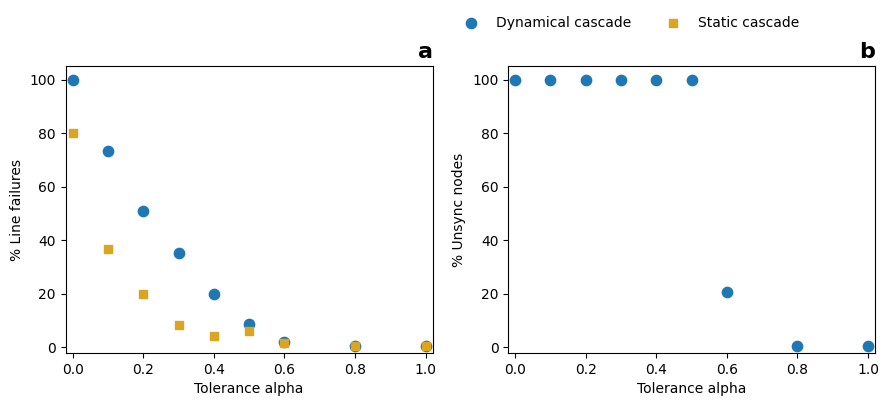

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].scatter(alpha_sweep_table['alpha'], alpha_sweep_table['dynamic_line_failures_percent'], color='tab:blue', s=55, label='Dynamical cascade')
axes[0].scatter(alpha_sweep_table['alpha'], alpha_sweep_table['static_line_failures_percent'], color='goldenrod', marker='s', s=40, label='Static cascade')
axes[0].set_xlabel('Tolerance alpha')
axes[0].set_ylabel('% Line failures')
axes[0].set_ylim(-2, 105)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_title('a', loc='right', fontsize=16, fontweight='bold')

axes[1].scatter(alpha_sweep_table['alpha'], alpha_sweep_table['dynamic_unsynchronized_nodes_percent'], color='tab:blue', s=55)
axes[1].set_xlabel('Tolerance alpha')
axes[1].set_ylabel('% Unsync nodes')
axes[1].set_ylim(-2, 105)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_title('b', loc='right', fontsize=16, fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Panel a shows that cascade size decreases strongly as the tolerance parameter $\alpha$ increases, for both the dynamical and the static model. The dynamical cascade is consistently more damaging than the static one at low and intermediate tolerance values, while both approaches predict almost no line failures once $\alpha$ becomes sufficiently large.

Panel b shows that the fraction of unsynchronized nodes remains extremely high for small and medium tolerance values and only drops sharply for large $\alpha$. This indicates that increasing line tolerance not only limits structural damage, but also helps the system recover dynamical synchronization.


## Part 4: Distribution of Cascade Sizes

### 4.1 Spanish Distributed Power

I now look at the full distribution of final cascade sizes. To match the figure of the paper, I evaluate all valid trigger lines for the Spanish distributed-power grid and compare two values of $\alpha$ that were also used in the paper.

In [48]:
alpha_1 = 0.55
alpha_2 = 0.85
distribution_time_step = 0.15
distribution_trigger_stride = 1
distribution_trigger_lines = valid_trigger_lines[::distribution_trigger_stride]
distribution_cache_version = 2
distribution_cache_file = cache_dir / f'distribution_panel_a_{country}_{scenario}.pkl'

distribution_cache = None

if distribution_cache_file.exists():
    with distribution_cache_file.open('rb') as file:
        loaded_distribution_cache = pickle.load(file)

    same_settings = (
        loaded_distribution_cache.get('country') == country and
        loaded_distribution_cache.get('scenario') == scenario and
        loaded_distribution_cache.get('distribution_time_step') == distribution_time_step and
        loaded_distribution_cache.get('distribution_trigger_stride') == distribution_trigger_stride and
        loaded_distribution_cache.get('distribution_cache_version') == distribution_cache_version and
        loaded_distribution_cache.get('alpha_values') == [alpha_1, alpha_2])

    if same_settings:
        distribution_cache = loaded_distribution_cache

if distribution_cache is None:
    distribution_cache = {
        'country': country,
        'scenario': scenario,
        'distribution_time_step': distribution_time_step,
        'distribution_trigger_stride': distribution_trigger_stride,
        'distribution_cache_version': distribution_cache_version,
        'alpha_values': [alpha_1, alpha_2],
        'rows': []}

distribution_rows = list(distribution_cache['rows'])
finished_pairs = {(round(row['alpha'], 4), tuple(row['trigger_line'])) for row in distribution_rows}

for alpha_value in [alpha_1, alpha_2]:
    for trigger_edge in tqdm(distribution_trigger_lines, desc=f'distribution alpha = {alpha_value:.2f}'):
        pair_key = (round(alpha_value, 4), tuple(trigger_edge))

        if pair_key in finished_pairs:
            continue

        line_failure_count, unsynchronized_count = run_cascade_for_trigger_with_alpha(trigger_edge,
                                                                                       alpha_value,
                                                                                       t_end_for_curve=20.0,
                                                                                       local_time_step=distribution_time_step)

        distribution_rows.append({
            'alpha': float(alpha_value),
            'trigger_line': tuple(trigger_edge),
            'line_failures': int(line_failure_count),
            'unsynchronized_nodes': int(unsynchronized_count)})

        finished_pairs.add(pair_key)

        distribution_cache_payload = {
            'country': country,
            'scenario': scenario,
            'distribution_time_step': distribution_time_step,
            'distribution_trigger_stride': distribution_trigger_stride,
            'distribution_cache_version': distribution_cache_version,
            'alpha_values': [alpha_1, alpha_2],
            'rows': distribution_rows}

        with distribution_cache_file.open('wb') as file:
            pickle.dump(distribution_cache_payload, file)

distribution_table = pd.DataFrame(distribution_rows)
distribution_table = distribution_table.sort_values(['alpha', 'line_failures']).reset_index(drop=True)

distribution alpha = 0.55:   0%|          | 0/173 [00:00<?, ?it/s]

distribution alpha = 0.85:   0%|          | 0/173 [00:00<?, ?it/s]

The histogram compares the distribution of final line-failure counts for the two tolerance values using all valid trigger lines.

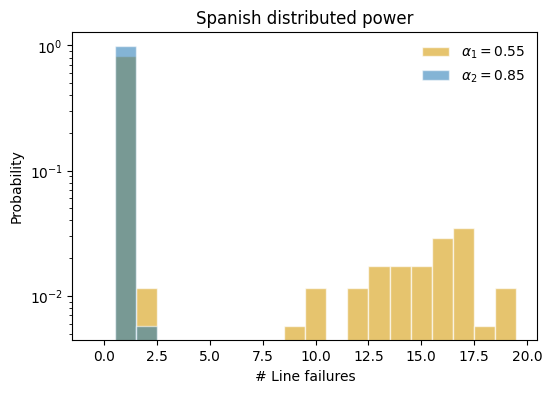

In [54]:
line_failures_alpha_1 = distribution_table.loc[distribution_table['alpha'] == alpha_1, 'line_failures'].to_numpy()
line_failures_alpha_2 = distribution_table.loc[distribution_table['alpha'] == alpha_2, 'line_failures'].to_numpy()

bin_edges = np.arange(0, distribution_table['line_failures'].max() + 2) - 0.5

plt.figure(figsize=(6, 4))
plt.hist(line_failures_alpha_1, bins=bin_edges, density=True, alpha=0.65, color='goldenrod', edgecolor='white', label=fr'$\alpha_1 = {alpha_1}$')
plt.hist(line_failures_alpha_2, bins=bin_edges, density=True, alpha=0.55, color='tab:blue', edgecolor='white', label=fr'$\alpha_2 = {alpha_2}$')
plt.yscale('log')
plt.xlabel('# Line failures')
plt.ylabel('Probability')
plt.title(f'{country} {scenario.replace("Power", " power").replace("Coupling", " coupling").lower()}')
plt.legend(frameon=False)
plt.show()

The histogram shows that for $\alpha_2 = 0.85$ almost all trigger lines lead to only one or two failures, whereas for the lower tolerance $\alpha_1 = 0.55$ cascades are much larger and spread across a broad range of failure sizes.


### 4.2 Spanish Scenarios

Next Icompute the same cascade-size distribution for all three Spanish scenarios.

To compare several Spanish scenarios, I reuse the same cascade logic as above, but rebuild the grid-specific quantities separately for each scenario. This keeps the calculations consistent while allowing scenario-specific caches (as the code ran forever...) and alpha values.

However, the code becomes a bit messy I'm sorry...

In [ ]:
spanish_scenarios = ['CentralizedPower', 'DistributedPower', 'HeterogeneousCoupling']
spanish_scenarios_to_run = ['CentralizedPower', 'DistributedPower', 'HeterogeneousCoupling']
spanish_alpha_pairs = { # all values from the paper 
    'CentralizedPower': (0.5, 0.7),
    'DistributedPower': (0.55, 0.85),
    'HeterogeneousCoupling': (0.55, 0.8)}
spanish_max_trigger_lines = {
    'CentralizedPower': 100, # for computing reasons
    'DistributedPower': None,
    'HeterogeneousCoupling': 100}
spanish_distribution_tables = {}

I first rebuild the fixed point and the valid trigger lines for a selected scenario. This is the same as in Part 2, but keeps the quantities local so that different scenarios do not overwrite one another.

In [ ]:
def build_grid_context(country_name, scenario_name):
    """
    Build and return the grid-specific variables needed to simulate cascades for a given country and scenario.
    """
    K_local = matrices[f'{country_name}{scenario_name}'].to_numpy(dtype=float)
    P_local = powers[f'{country_name}{scenario_name}'][0].to_numpy(dtype=float)
    number_of_nodes_local = len(P_local)
    starting_point_local = np.zeros(number_of_nodes_local - 1)

    def fixed_point_equations_local(theta_rest):
        """
        Return the fixed-point residuals for the local grid context and a given active coupling matrix.
        """
        theta = np.concatenate(([0.0], theta_rest))
        residuals = []

        for i in range(1, number_of_nodes_local):
            coupling_sum = 0.0

            for j in range(number_of_nodes_local):
                coupling_sum += K_local[i, j] * np.sin(theta[j] - theta[i])

            residuals.append(P_local[i] + coupling_sum)

        return np.array(residuals)

    fixed_point_solution_local = root(fixed_point_equations_local, starting_point_local)
    theta_fixed_local = np.concatenate(([0.0], fixed_point_solution_local.x))

    edge_flows_local = []

    for i in range(number_of_nodes_local):
        for j in range(i + 1, number_of_nodes_local):
            if K_local[i, j] > 0:
                flow = abs(K_local[i, j] * np.sin(theta_fixed_local[i] - theta_fixed_local[j]))
                edge_flows_local.append({'node_i': i, 'node_j': j, 'coupling': K_local[i, j], 'initial_flow': flow})

    edge_flow_table_local = pd.DataFrame(edge_flows_local)
    edge_flow_table_local = edge_flow_table_local.sort_values('initial_flow', ascending=False).reset_index(drop=True)

    redundant_lines_local = edge_flow_table_local[edge_flow_table_local['initial_flow'] < 1e-8].copy()
    redundant_lines_python_local = set(zip(redundant_lines_local['node_i'], redundant_lines_local['node_j']))
    list_of_edges_local = list(zip(edge_flow_table_local['node_i'], edge_flow_table_local['node_j']))
    valid_trigger_lines_local = [edge for edge in list_of_edges_local if edge not in redundant_lines_python_local]

    initial_theta_local = theta_fixed_local.copy()
    initial_omega_local = np.zeros(number_of_nodes_local)
    initial_state_local = np.concatenate([initial_theta_local, initial_omega_local])

    return {
        'country': country_name,
        'scenario': scenario_name,
        'K': K_local,
        'P': P_local,
        'number_of_nodes': number_of_nodes_local,
        'list_of_edges': list_of_edges_local,
        'valid_trigger_lines': valid_trigger_lines_local,
        'initial_state': initial_state_local,
        'omega_not_synchronized_threshold': 0.02 * 2 * np.pi} # from the author's code

Next, I apply the dynamic cascade model inside such a local scenario context. The logic is the same as before: remove the trigger line, integrate the swing equations, remove overloaded lines and repeat until the cascade stops.

In [57]:
def run_cascade_for_trigger_with_alpha_in_context(context, trigger_line, alpha_value, t_end_for_curve=20.0, local_time_step=0.15):
    """
    Simulate the dynamic cascade for a given trigger line and tolerance value within a local grid context.
    """
    K_local = context['K']
    P_local = context['P']
    number_of_nodes_local = context['number_of_nodes']
    initial_state_local = context['initial_state']
    omega_not_synchronized_threshold_local = context['omega_not_synchronized_threshold']
    I_local = np.ones(number_of_nodes_local)

    def swing_equation_with_matrix_local(t, state, active_matrix):
        """
        Return the time derivatives of the local swing equation for a given system state and active coupling matrix.
        """
        theta = state[:number_of_nodes_local]
        omega = state[number_of_nodes_local:]
        dtheta_dt = omega
        domega_dt = np.zeros(number_of_nodes_local)

        for i in range(number_of_nodes_local):
            coupling_sum = 0.0

            for j in range(number_of_nodes_local):
                coupling_sum += active_matrix[i, j] * np.sin(theta[j] - theta[i])

            domega_dt[i] = (P_local[i] - gamma * omega[i] + coupling_sum) / I_local[i]

        return np.concatenate([dtheta_dt, domega_dt])

    active_matrix = K_local.copy()
    current_time = t_start
    current_state = initial_state_local.copy()
    lines_cut_local = [{'node_i': trigger_line[0], 'node_j': trigger_line[1], 'failure_time': t_trigger, 'reason': 'trigger'}]
    cascade_segments_local = []
    candidate_lines_for_trigger = [edge for edge in context['list_of_edges'] if edge != tuple(trigger_line)]

    while current_time < t_end_for_curve:
        segment_end = t_trigger if current_time < t_trigger else t_end_for_curve

        if segment_end - current_time < 1e-12:
            break

        segment_times = np.arange(current_time, segment_end, local_time_step)
        segment_times = segment_times[(segment_times >= current_time) & (segment_times <= segment_end)]

        if len(segment_times) == 0 or abs(segment_times[-1] - segment_end) > 1e-12:
            segment_times = np.append(segment_times, segment_end)

        segment_times = np.unique(np.round(segment_times, 12))

        segment_solution = solve_ivp(swing_equation_with_matrix_local,
                                     (current_time, segment_end), current_state,
                                     t_eval=segment_times, args=(active_matrix,), rtol=1e-6, atol=1e-8)

        cascade_segments_local.append(segment_solution)

        if current_time < t_trigger:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_trigger
            active_matrix[trigger_line[0], trigger_line[1]] = 0.0
            active_matrix[trigger_line[1], trigger_line[0]] = 0.0
            continue

        theta_solution = segment_solution.y[:number_of_nodes_local]
        overloaded_now = []
        failure_index = None

        for time_index, current_segment_time in enumerate(segment_solution.t):
            overloaded_at_time = []

            for edge in candidate_lines_for_trigger:
                i, j = edge

                if active_matrix[i, j] == 0:
                    continue

                flow = abs(active_matrix[i, j] * np.sin(theta_solution[i, time_index] - theta_solution[j, time_index]))
                threshold = alpha_value * K_local[i, j]

                if flow >= threshold:
                    overloaded_at_time.append({
                        'node_i': i,
                        'node_j': j,
                        'failure_time': current_segment_time,
                        'flow': flow,
                        'threshold': threshold})

            if len(overloaded_at_time) > 0:
                overloaded_now = overloaded_at_time
                failure_index = time_index
                break

        if len(overloaded_now) == 0:
            current_state = segment_solution.y[:, -1].copy()
            current_time = t_end_for_curve
            break

        current_state = segment_solution.y[:, failure_index].copy()
        current_time = overloaded_now[0]['failure_time']

        for failed_line in overloaded_now:
            i = failed_line['node_i']
            j = failed_line['node_j']
            active_matrix[i, j] = 0.0
            active_matrix[j, i] = 0.0
            failed_line['reason'] = 'overload'
            lines_cut_local.append(failed_line)

    lines_cut_table_local = pd.DataFrame(lines_cut_local)
    lines_cut_table_local = lines_cut_table_local.sort_values('failure_time').reset_index(drop=True)

    final_omega_local = cascade_segments_local[-1].y[number_of_nodes_local:, -1]
    nodes_not_synchronized_local = np.where(np.abs(final_omega_local) > omega_not_synchronized_threshold_local)[0]

    return len(lines_cut_table_local), len(nodes_not_synchronized_local)


Finally, I scan the selected trigger lines for each scenario.

In [58]:
def compute_distribution_table_for_context(context, alpha_values_local, distribution_time_step=0.15, distribution_trigger_stride=1, distribution_cache_version=2, max_trigger_lines=None, random_seed=42):
    """
    Compute or load the line-failure distributions for a given grid context and a set of tolerance values.
    """
    distribution_trigger_lines_local = context['valid_trigger_lines'][::distribution_trigger_stride]

    if max_trigger_lines is not None and len(distribution_trigger_lines_local) > max_trigger_lines:
        rng = np.random.default_rng(random_seed)
        sampled_indices = np.sort(rng.choice(len(distribution_trigger_lines_local), size=max_trigger_lines, replace=False))
        distribution_trigger_lines_local = [distribution_trigger_lines_local[index] for index in sampled_indices]

    distribution_cache_file_local = cache_dir / f"distribution_panel_a_{context['country']}_{context['scenario']}.pkl"
    distribution_cache_local = None

    if distribution_cache_file_local.exists():
        with distribution_cache_file_local.open('rb') as file:
            loaded_distribution_cache_local = pickle.load(file)

        loaded_max_trigger_lines = loaded_distribution_cache_local.get('max_trigger_lines')
        loaded_random_seed = loaded_distribution_cache_local.get('random_seed')
        compatible_sampling = (
            (loaded_max_trigger_lines == max_trigger_lines and loaded_random_seed == random_seed) or
            (max_trigger_lines is None and loaded_max_trigger_lines is None))

        same_settings = (
            loaded_distribution_cache_local.get('country') == context['country'] and
            loaded_distribution_cache_local.get('scenario') == context['scenario'] and
            loaded_distribution_cache_local.get('distribution_time_step') == distribution_time_step and
            loaded_distribution_cache_local.get('distribution_trigger_stride') == distribution_trigger_stride and
            loaded_distribution_cache_local.get('distribution_cache_version') == distribution_cache_version and
            compatible_sampling and
            loaded_distribution_cache_local.get('alpha_values') == list(alpha_values_local))

        if same_settings:
            distribution_cache_local = loaded_distribution_cache_local
        else:
            backup_index = 1
            backup_file_local = distribution_cache_file_local.with_name(
                f"{distribution_cache_file_local.stem}_backup_{backup_index}.pkl")

            while backup_file_local.exists():
                backup_index += 1
                backup_file_local = distribution_cache_file_local.with_name(
                    f"{distribution_cache_file_local.stem}_backup_{backup_index}.pkl")

            with distribution_cache_file_local.open('rb') as source_file, backup_file_local.open('wb') as backup_file:
                backup_file.write(source_file.read())

    if distribution_cache_local is None:
        distribution_cache_local = {
            'country': context['country'],
            'scenario': context['scenario'],
            'distribution_time_step': distribution_time_step,
            'distribution_trigger_stride': distribution_trigger_stride,
            'distribution_cache_version': distribution_cache_version,
            'max_trigger_lines': max_trigger_lines,
            'random_seed': random_seed,
            'alpha_values': list(alpha_values_local),
            'rows': []}

    distribution_rows_local = list(distribution_cache_local['rows'])
    finished_pairs_local = {(round(row['alpha'], 4), tuple(row['trigger_line'])) for row in distribution_rows_local}

    for alpha_value in alpha_values_local:
        for trigger_edge in tqdm(distribution_trigger_lines_local,
                                 desc=f"{context['scenario']} alpha = {alpha_value:.2f}",
                                 leave=False):
            pair_key = (round(float(alpha_value), 4), tuple(trigger_edge))

            if pair_key in finished_pairs_local:
                continue

            line_failure_count, unsynchronized_count = run_cascade_for_trigger_with_alpha_in_context(
                context,
                trigger_edge,
                alpha_value,
                t_end_for_curve=20.0,
                local_time_step=distribution_time_step)

            distribution_rows_local.append({
                'alpha': float(alpha_value),
                'trigger_line': tuple(trigger_edge),
                'line_failures': int(line_failure_count),
                'unsynchronized_nodes': int(unsynchronized_count)})

            finished_pairs_local.add(pair_key)

            distribution_cache_payload_local = {
                'country': context['country'],
                'scenario': context['scenario'],
                'distribution_time_step': distribution_time_step,
                'distribution_trigger_stride': distribution_trigger_stride,
                'distribution_cache_version': distribution_cache_version,
                'max_trigger_lines': max_trigger_lines,
                'random_seed': random_seed,
                'alpha_values': list(alpha_values_local),
                'rows': distribution_rows_local}

            with distribution_cache_file_local.open('wb') as file:
                pickle.dump(distribution_cache_payload_local, file)

    distribution_table_local = pd.DataFrame(distribution_rows_local)
    return distribution_table_local.sort_values(['alpha', 'line_failures']).reset_index(drop=True)


DistributedPower alpha = 0.55:   0%|          | 0/173 [00:00<?, ?it/s]

DistributedPower alpha = 0.85:   0%|          | 0/173 [00:00<?, ?it/s]

CentralizedPower alpha = 0.50:   0%|          | 0/100 [00:00<?, ?it/s]

CentralizedPower alpha = 0.70:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.55:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.80:   0%|          | 0/100 [00:00<?, ?it/s]

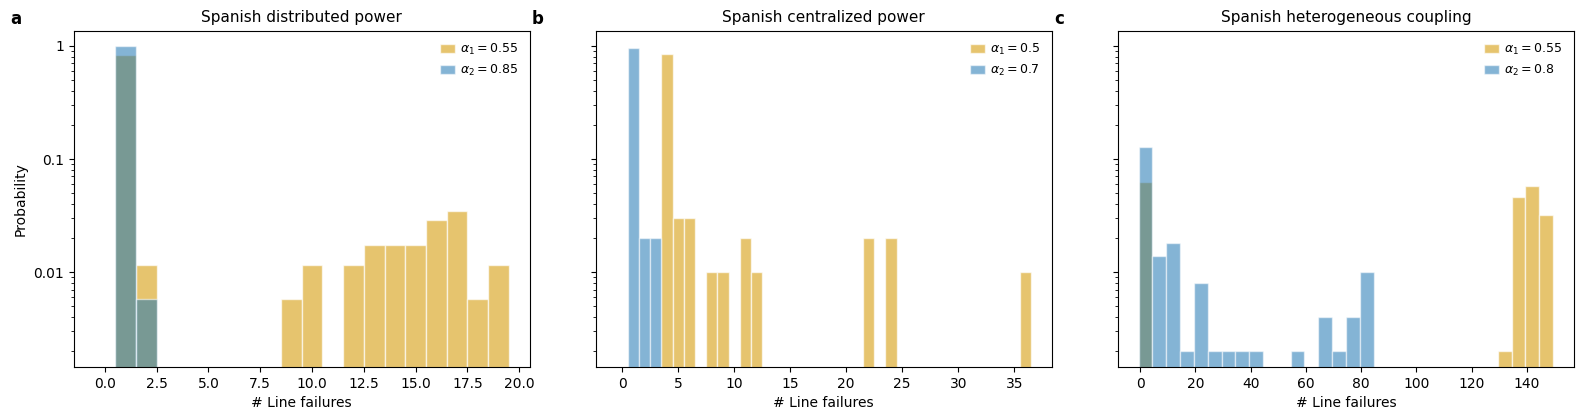

In [61]:
plot_scenarios = ['DistributedPower', 'CentralizedPower', 'HeterogeneousCoupling']

fig, axes = plt.subplots(1, len(plot_scenarios), figsize=(5.3 * len(plot_scenarios), 4.3), sharey=True)

if len(plot_scenarios) == 1:
    axes = [axes]

for panel_index, (ax, scenario_name) in enumerate(zip(axes, plot_scenarios)):
    alpha_1_local, alpha_2_local = spanish_alpha_pairs[scenario_name]
    max_trigger_lines_local = spanish_max_trigger_lines[scenario_name]
    context = build_grid_context('Spanish', scenario_name)
    distribution_table_local = compute_distribution_table_for_context(
        context,
        [alpha_1_local, alpha_2_local],
        distribution_time_step=distribution_time_step,
        distribution_trigger_stride=1,
        distribution_cache_version=distribution_cache_version,
        max_trigger_lines=max_trigger_lines_local,
        random_seed=42)
    spanish_distribution_tables[scenario_name] = distribution_table_local

    line_failures_alpha_1 = distribution_table_local.loc[distribution_table_local['alpha'] == alpha_1_local, 'line_failures'].to_numpy()
    line_failures_alpha_2 = distribution_table_local.loc[distribution_table_local['alpha'] == alpha_2_local, 'line_failures'].to_numpy()
    if scenario_name == 'HeterogeneousCoupling':
        bin_width = 5
        bin_edges = np.arange(-0.5, distribution_table_local['line_failures'].max() + bin_width + 0.5, bin_width)
    else:
        bin_edges = np.arange(0, distribution_table_local['line_failures'].max() + 2) - 0.5

    ax.hist(line_failures_alpha_1, bins=bin_edges, density=True, alpha=0.65, color='goldenrod', edgecolor='white', label=fr'$\alpha_1 = {alpha_1_local}$')
    ax.hist(line_failures_alpha_2, bins=bin_edges, density=True, alpha=0.55, color='tab:blue', edgecolor='white', label=fr'$\alpha_2 = {alpha_2_local}$')
    ax.set_yscale('log')
    ax.set_xlabel('# Line failures')
    ax.set_title(f"Spanish {scenario_name.replace('Power', ' power').replace('Coupling', ' coupling').lower()}", fontsize=11)
    ax.text(-0.14, 1.02, 'abc'[panel_index], transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.legend(frameon=False, loc='upper right', fontsize=9, handlelength=1.2, handletextpad=0.4)

axes[0].set_ylabel('Probability')
axes[0].set_yticks([1, 0.1, 0.01])
axes[0].set_yticklabels(['1', '0.1', '0.01'])
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

plt.tight_layout()
plt.show()

### 4.3 French Scenarios

I now repeat the same comparison for the French grid, again using scenario-specific alpha values and the same cached workflow.

In [62]:
french_scenarios = ['DistributedPower', 'CentralizedPower', 'HeterogeneousCoupling']
french_alpha_pairs = {
    'DistributedPower': (0.7, 0.9),
    'CentralizedPower': (0.85, 0.95),
    'HeterogeneousCoupling': (0.5, 0.75)}
french_max_trigger_lines = {
    'DistributedPower': 100,
    'CentralizedPower': 100,
    'HeterogeneousCoupling': 100}
french_distribution_tables = {}

DistributedPower alpha = 0.70:   0%|          | 0/100 [00:00<?, ?it/s]

DistributedPower alpha = 0.90:   0%|          | 0/100 [00:00<?, ?it/s]

CentralizedPower alpha = 0.85:   0%|          | 0/100 [00:00<?, ?it/s]

CentralizedPower alpha = 0.95:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.50:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.75:   0%|          | 0/100 [00:00<?, ?it/s]

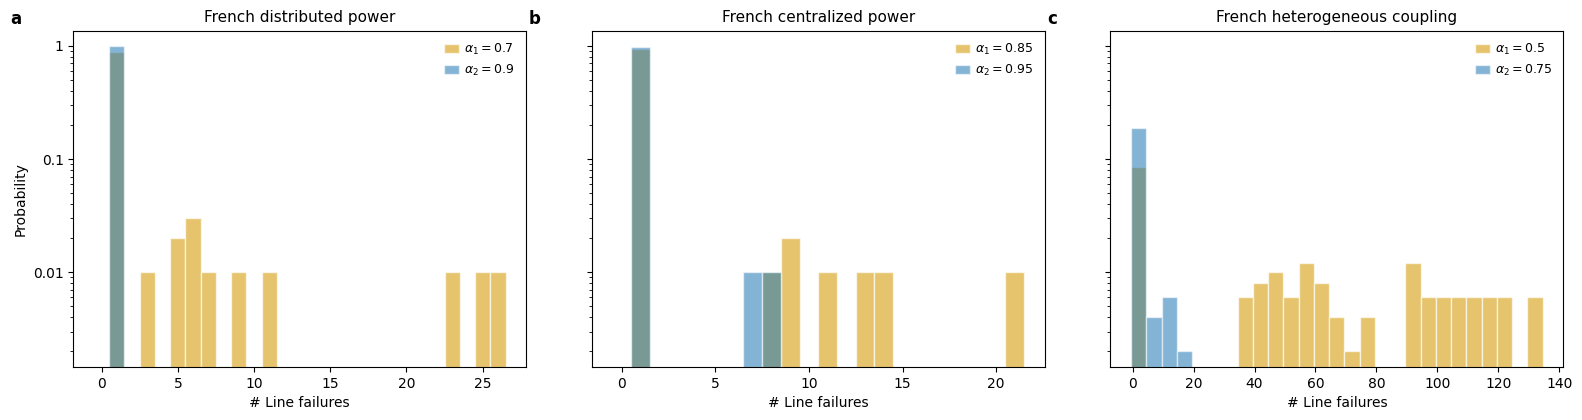

In [64]:
fig, axes = plt.subplots(1, len(french_scenarios), figsize=(5.3 * len(french_scenarios), 4.3), sharey=True)

if len(french_scenarios) == 1:
    axes = [axes]

for panel_index, (ax, scenario_name) in enumerate(zip(axes, french_scenarios)):
    alpha_1_local, alpha_2_local = french_alpha_pairs[scenario_name]
    max_trigger_lines_local = french_max_trigger_lines[scenario_name]
    context = build_grid_context('French', scenario_name)
    distribution_table_local = compute_distribution_table_for_context(
        context,
        [alpha_1_local, alpha_2_local],
        distribution_time_step=distribution_time_step,
        distribution_trigger_stride=1,
        distribution_cache_version=distribution_cache_version,
        max_trigger_lines=max_trigger_lines_local,
        random_seed=42)
    french_distribution_tables[scenario_name] = distribution_table_local

    line_failures_alpha_1 = distribution_table_local.loc[distribution_table_local['alpha'] == alpha_1_local, 'line_failures'].to_numpy()
    line_failures_alpha_2 = distribution_table_local.loc[distribution_table_local['alpha'] == alpha_2_local, 'line_failures'].to_numpy()
    if scenario_name == 'HeterogeneousCoupling':
        bin_width = 5
        bin_edges = np.arange(-0.5, distribution_table_local['line_failures'].max() + bin_width + 0.5, bin_width)
    else:
        bin_edges = np.arange(0, distribution_table_local['line_failures'].max() + 2) - 0.5

    ax.hist(line_failures_alpha_1, bins=bin_edges, density=True, alpha=0.65, color='goldenrod', edgecolor='white', label=fr'$\alpha_1 = {alpha_1_local}$')
    ax.hist(line_failures_alpha_2, bins=bin_edges, density=True, alpha=0.55, color='tab:blue', edgecolor='white', label=fr'$\alpha_2 = {alpha_2_local}$')
    ax.set_yscale('log')
    ax.set_xlabel('# Line failures')
    ax.set_title(f"French {scenario_name.replace('Power', ' power').replace('Coupling', ' coupling').lower()}", fontsize=11)
    ax.text(-0.14, 1.02, 'abc'[panel_index], transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.legend(frameon=False, loc='upper right', fontsize=9, handlelength=1.2, handletextpad=0.4)

axes[0].set_ylabel('Probability')
axes[0].set_yticks([1, 0.1, 0.01])
axes[0].set_yticklabels(['1', '0.1', '0.01'])
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

plt.tight_layout()
plt.show()

### 4.5 Combined Spain and France

For the appendix-style overview, I now place the Spanish and French scenario histograms into one common 2x3 figure.

DistributedPower alpha = 0.55:   0%|          | 0/173 [00:00<?, ?it/s]

DistributedPower alpha = 0.85:   0%|          | 0/173 [00:00<?, ?it/s]

CentralizedPower alpha = 0.50:   0%|          | 0/100 [00:00<?, ?it/s]

CentralizedPower alpha = 0.70:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.55:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistributedPower alpha = 0.90:   0%|          | 0/100 [00:00<?, ?it/s]

CentralizedPower alpha = 0.85:   0%|          | 0/100 [00:00<?, ?it/s]

CentralizedPower alpha = 0.95:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.50:   0%|          | 0/100 [00:00<?, ?it/s]

HeterogeneousCoupling alpha = 0.75:   0%|          | 0/100 [00:00<?, ?it/s]

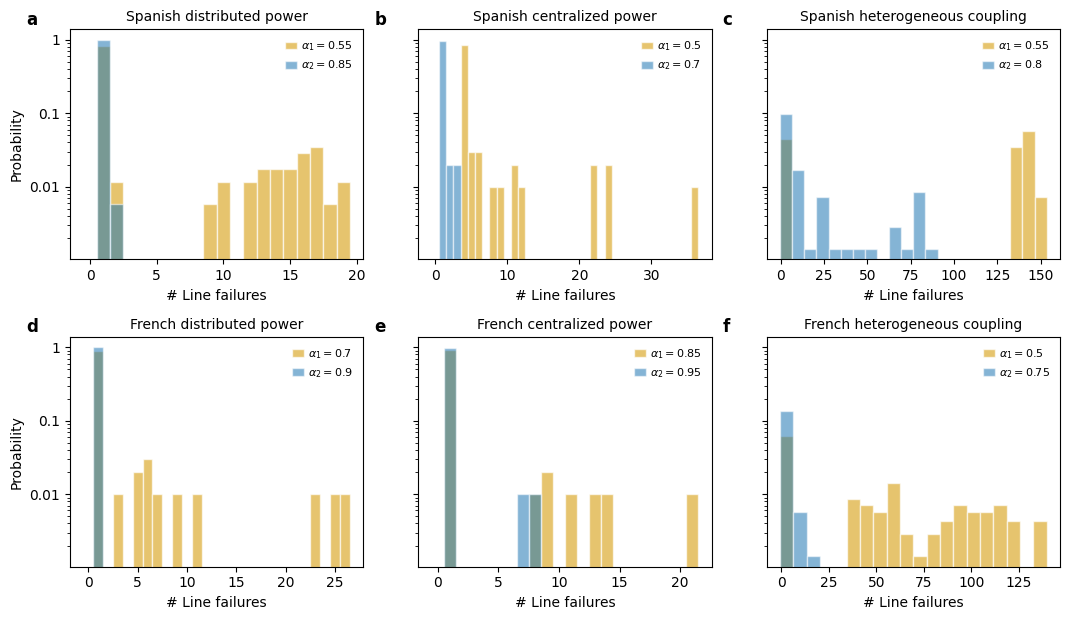

In [65]:
combined_plot_config = [
    ('Spanish', 'DistributedPower', spanish_alpha_pairs['DistributedPower'], spanish_max_trigger_lines['DistributedPower']),
    ('Spanish', 'CentralizedPower', spanish_alpha_pairs['CentralizedPower'], spanish_max_trigger_lines['CentralizedPower']),
    ('Spanish', 'HeterogeneousCoupling', spanish_alpha_pairs['HeterogeneousCoupling'], spanish_max_trigger_lines['HeterogeneousCoupling']),
    ('French', 'DistributedPower', french_alpha_pairs['DistributedPower'], french_max_trigger_lines['DistributedPower']),
    ('French', 'CentralizedPower', french_alpha_pairs['CentralizedPower'], french_max_trigger_lines['CentralizedPower']),
    ('French', 'HeterogeneousCoupling', french_alpha_pairs['HeterogeneousCoupling'], french_max_trigger_lines['HeterogeneousCoupling'])]

fig, axes = plt.subplots(2, 3, figsize=(10.8, 6.3), sharey=True)
axes = axes.flatten()

for panel_index, (ax, (country_name, scenario_name, alpha_pair, max_trigger_lines_local)) in enumerate(zip(axes, combined_plot_config)):
    alpha_1_local, alpha_2_local = alpha_pair
    context = build_grid_context(country_name, scenario_name)
    distribution_table_local = compute_distribution_table_for_context(
        context,
        [alpha_1_local, alpha_2_local],
        distribution_time_step=distribution_time_step,
        distribution_trigger_stride=1,
        distribution_cache_version=distribution_cache_version,
        max_trigger_lines=max_trigger_lines_local,
        random_seed=42)

    line_failures_alpha_1 = distribution_table_local.loc[distribution_table_local['alpha'] == alpha_1_local, 'line_failures'].to_numpy()
    line_failures_alpha_2 = distribution_table_local.loc[distribution_table_local['alpha'] == alpha_2_local, 'line_failures'].to_numpy()
    if scenario_name == 'HeterogeneousCoupling':
        bin_width = 7
        bin_edges = np.arange(-0.5, distribution_table_local['line_failures'].max() + bin_width + 0.5, bin_width)
    else:
        bin_edges = np.arange(0, distribution_table_local['line_failures'].max() + 2) - 0.5

    ax.hist(line_failures_alpha_1, bins=bin_edges, density=True, alpha=0.65, color='goldenrod', edgecolor='white', label=fr'$\alpha_1 = {alpha_1_local}$')
    ax.hist(line_failures_alpha_2, bins=bin_edges, density=True, alpha=0.55, color='tab:blue', edgecolor='white', label=fr'$\alpha_2 = {alpha_2_local}$')
    ax.set_yscale('log')
    ax.set_xlabel('# Line failures')
    ax.set_title(f"{country_name} {scenario_name.replace('Power', ' power').replace('Coupling', ' coupling').lower()}", fontsize=10)
    ax.text(-0.15, 1.02, 'abcdef'[panel_index], transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.legend(frameon=False, loc='upper right', fontsize=8, handlelength=1.1, handletextpad=0.35)

axes[0].set_ylabel('Probability')
axes[3].set_ylabel('Probability')
axes[0].set_yticks([1, 0.1, 0.01])
axes[0].set_yticklabels(['1', '0.1', '0.01'])
axes[3].set_yticks([1, 0.1, 0.01])
axes[3].set_yticklabels(['1', '0.1', '0.01'])

for ax in [axes[1], axes[2], axes[4], axes[5]]:
    ax.tick_params(labelleft=False)

plt.tight_layout()
plt.show()